# NB1 — ICDM CAPGD Protocol Grid

**The protocol-sensitivity core (spec §4).** Regenerates the entire CAPGD
evidence base fresh and *same-model*: one trained MLP per
`(dataset, defence, seed)`, reused across every ε and every protocol
(identical `model_weight_hash`).

Protocols per run:
- **A_unconstrained** — stock CAPGD, no projection / no mask.
- **B_posthoc_filter** — feasibility filter on A's saved examples (infeasible → revert to clean). *Derived, no new attack.*
- **C1_projection** — CAPGD + per-step projection (LCLD g1+term; IEEE/Sparkov OHE blocks).
- **C2_mask_projection** — C1 + attacker-capability mutability mask.

CCFD (no binding constraints, negative control) runs **A** and **B(=A)** only.
ε sweep `{0.01,0.05,0.1,0.15,0.2}` on the no-defence MLP; defended configs at ε=0.1.

**Bootstrap cells 1–5** mirror the existing projection notebooks (Drive mount,
repo clone, deps install → restart, dataset symlinks).

Outputs: adversarial parquet under `results/adv_examples/icdm_capgd_grid/`;
CSV deliverables + figures under `results/icdm_2026/`.

In [1]:
# Cell 1: Verify GPU
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = getattr(props, "total_memory", getattr(props, "total_mem", 0)) / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU")

GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


In [2]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
for subdir in ["data", "results", "results/adv_examples", "results/icdm_2026"]:
    os.makedirs(os.path.join(DRIVE_ROOT, subdir), exist_ok=True)
print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [3]:
# Cell 3: Clone or update repo
import os, shutil

REPO_URL = "https://github.com/iHaydenzZ/Capstone_FraudBench.git"
REPO_DIR = "/content/Capstone_FraudBench"

if os.path.exists(os.path.join(REPO_DIR, ".git")):
    os.chdir(REPO_DIR)
    !git pull
else:
    os.chdir("/content")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    !git clone {REPO_URL} {REPO_DIR}
    os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")
!git log --oneline -3

Cloning into '/content/Capstone_FraudBench'...
remote: Enumerating objects: 1205, done.
remote: Counting objects: 100% (366/366), done.
remote: Compressing objects: 100% (251/251), done.
remote: Total 1205 (delta 199), reused 264 (delta 111), pack-reused 839 (from 1)
Receiving objects: 100% (1205/1205), 4.86 MiB | 19.75 MiB/s, done.
Resolving deltas: 100% (737/737), done.
Working directory: /content/Capstone_FraudBench
5e2c362 (HEAD -> master, origin/master, origin/HEAD) feat(notebooks): NB1 ICDM CAPGD protocol grid (same-model A/B/C1/C2 + eps sweep)
c959e1b feat(attacks): reusable constraint-aware CAPGD (C1/C2 projection + mask)
6b0515c feat(constraints): C2 attacker-capability mutability masks


In [4]:
# Cell 4: Install dependencies
!pip install "numpy<2.1" "scipy>=1.14,<1.15" "scikit-learn>=1.5" -q 2>&1 | tail -5
!pip install -e . --no-deps -q 2>&1 | tail -5
!pip install "numba>=0.61" -q 2>&1 | tail -3
!pip install xgboost torch art pyyaml joblib pandas matplotlib pyarrow -q 2>&1 | tail -3

# --- IMPORTANT ---
# After this cell finishes, restart the runtime:
#   Runtime > Restart session  (or Ctrl+M then .)
# Then skip this cell and continue from Cell 5.
print("\n>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 69.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.4/610.4 kB 46.9 MB/s eta 0:00:00

>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<


In [1]:
# Cell 5: Symlink datasets from Google Drive
import os

DRIVE_DATA = "/content/drive/MyDrive/FraudBench/data"
DATASETS_DIR = "/content/Capstone_FraudBench/datasets"

for dataset_dir in ["CCFD", "ieee-fraud-detection", "LCLD", "Sparkov"]:
    src = os.path.join(DRIVE_DATA, dataset_dir)
    dst = os.path.join(DATASETS_DIR, dataset_dir)
    if os.path.islink(dst):
        os.unlink(dst)
    if os.path.exists(src):
        os.symlink(src, dst)
        print(f"  Linked: {dataset_dir}/")
    else:
        print(f"  NOT FOUND: {dataset_dir}/ -- upload to {src}")

print("Dataset symlinks ready.")

  Linked: CCFD/
  Linked: ieee-fraud-detection/
  Linked: LCLD/
  Linked: Sparkov/
Dataset symlinks ready.


In [2]:
# Cell 6: Configuration and imports
import os, time, random, hashlib
import numpy as np
import pandas as pd
import torch

from datasets.loader import load_dataset
from datasets.splitter import split_dataset
from preprocessing.processor import DataPreprocessor
from constraints.schema import ConstraintSchema
from constraints.validator import EVAL_TOL
from constraints.feasibility import evaluate_feasibility, get_constraint_names
from models.neural import NeuralModel
from defences.input_validation import InputValidator
from attacks.capgd import capgd_attack  # noqa: F401  (A path inside run_capgd_protocol)
from attacks.constrained_capgd import run_capgd_protocol
from evaluation.metrics import compute_metrics

# --- experiment axes (spec §4.2) ---
SEEDS = [42, 123, 456]
EPS_SWEEP = [0.01, 0.05, 0.1, 0.15, 0.2]   # no-defence MLP
DEFENCE_EPS = [0.1]                        # defended configs
STEPS = 10
SAMPLE_FRAC = 0.1                          # matches the anchor-producing runs
MODEL_PARAMS = {"epochs": 20, "hidden_dim": 128, "batch_size": 256, "lr": 0.001}

# (registry_name, loader_name, has_binding_constraints)
DATASETS = [
    ("CCFD", "ccfd", False),
    ("IEEE-CIS", "ieee_cis", True),
    ("LCLD", "lcld", True),
    ("Sparkov", "sparkov", True),
]
DEFENCES = ["none", "adversarial_training", "input_validation"]

NB, MODEL, ATTACK = "nb1_capgd_grid", "MLP", "CAPGD"

ADV_DIR = "results/adv_examples/icdm_capgd_grid"
OUT_DIR = "results/icdm_2026"
FIG_DIR = os.path.join(OUT_DIR, "figures")
for d in (ADV_DIR, OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)
RESULTS_CSV = os.path.join(OUT_DIR, "capgd_grid_results.csv")
PERCON_CSV = os.path.join(OUT_DIR, "capgd_grid_per_constraint.csv")
SUMMARY_CSV = os.path.join(OUT_DIR, "capgd_grid_summary.csv")

# Canonical long-format schema (spec §3.1).
RESULTS_COLUMNS = [
    "run_id", "notebook", "dataset", "model", "defence", "attack", "protocol",
    "seed", "epsilon", "same_model_group_id", "model_weight_hash", "n_test",
    "clean_pr_auc", "robust_pr_auc", "clean_roc_auc", "robust_roc_auc",
    "clean_accuracy", "robust_accuracy", "flipped_count", "feasible_count",
    "feasible_flipped_count", "fsr", "aggregate_feasibility",
    "main_failed_constraint", "attack_runtime_sec", "notes",
]

print(f"EVAL_TOL = {EVAL_TOL}  (named constant, thesis §3.10)")
print(f"Plan: {len(DATASETS)} datasets x {len(DEFENCES)} defences x {len(SEEDS)} seeds = "
      f"{len(DATASETS) * len(DEFENCES) * len(SEEDS)} MLP trainings")

EVAL_TOL = 1e-06  (named constant, thesis §3.10)
Plan: 4 datasets x 3 defences x 3 seeds = 36 MLP trainings


In [3]:
# Cell 7: Reproducibility helpers + same-model training per group
def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def weight_hash(model) -> str:
    """Stable 16-hex hash over the MLP state_dict (spec §1.9)."""
    net = getattr(model, "model", model)
    buf = b"".join(p.detach().cpu().numpy().tobytes() for p in net.state_dict().values())
    return hashlib.sha256(buf).hexdigest()[:16]


def train_group(registry_name, loader_name, defence, seed):
    """Train ONE MLP for a (dataset, defence, seed) group; reused for all
    protocols/eps. Returns the fitted model, preprocessor, processed test
    split, an eval-time predict fn (applies the input-validation defence to
    both clean and adversarial inputs), cached clean predictions, and hash."""
    set_all_seeds(seed)
    dataset = load_dataset(loader_name, config={"sample_frac": SAMPLE_FRAC})
    X_train, _X_val, X_test, y_train, _y_val, y_test = split_dataset(
        dataset, test_size=0.2, val_size=0.2, random_state=seed
    )
    pre = DataPreprocessor(dataset.feature_types)
    X_train_p = pre.fit_transform(X_train)
    X_test_p = pre.transform(X_test)
    proc_ft = {c: "numeric" for c in X_train_p.columns}
    schema = ConstraintSchema.from_data(X_train_p, proc_ft)

    params = dict(MODEL_PARAMS)
    if defence == "adversarial_training":
        params.update(
            adv_training=True,
            adv_epsilon=0.1,
            adv_schema=schema,
            adv_feature_names=X_train_p.columns.tolist(),
            adv_feature_types=proc_ft,
        )
    model = NeuralModel(params)
    t0 = time.time()
    model.fit(X_train_p, y_train)
    train_time = time.time() - t0

    validator = None
    if defence == "input_validation":
        validator = InputValidator(schema, mode="sanitise", z_threshold=3.0)
        validator.fit(X_train_p)

    def eval_predict(X):
        Xe = validator.transform(X) if validator is not None else X
        return model.predict_proba(Xe)

    clean_probs = eval_predict(X_test_p)
    grp = dict(
        model=model, pre=pre, schema=schema, proc_ft=proc_ft,
        X_test_p=X_test_p, y_test=y_test, eval_predict=eval_predict,
        clean_probs=clean_probs, hash=weight_hash(model),
    )
    print(f"  trained {registry_name}/{defence}/s{seed} in {train_time:.1f}s  "
          f"hash={grp['hash']}  proc_dim={X_test_p.shape[1]}")
    return grp

In [4]:
# Cell 8: Row builder (spec §3.1/§3.2), Protocol-B derivation, CSV append
def make_run_id(reg, defence, seed, eps, protocol):
    return f"{NB}__{reg}__{MODEL}__{defence}__s{seed}__e{eps}__{protocol}"


def build_rows(grp, reg, defence, seed, eps, protocol, X_adv, runtime, clean_feas):
    """Produce one §3.1 results row + its §3.2 per-constraint rows.

    flipped_count = positives the clean model caught (pred=1) that the attack
    flipped to negative; feasible_flipped additionally requires the adv row to
    pass the full feasibility conjunction (matches the anchor definition)."""
    adv_probs = grp["eval_predict"](X_adv)
    clean_m = compute_metrics(grp["y_test"], grp["clean_probs"])
    rob_m = compute_metrics(grp["y_test"], adv_probs)
    feas = evaluate_feasibility(reg, X_adv, preprocessor=grp["pre"])

    yv = grp["y_test"].values
    clean_pred = (grp["clean_probs"] >= 0.5).astype(int)
    adv_pred = (adv_probs >= 0.5).astype(int)
    pos = yv == 1
    fmask = feas.feasible_row_mask.values
    flipped = int(((clean_pred == 1) & (adv_pred == 0) & pos).sum())
    feas_flipped = int(((clean_pred == 1) & (adv_pred == 0) & pos & fmask).sum())
    fsr = (feas_flipped / flipped) if flipped > 0 else float("nan")

    rid = make_run_id(reg, defence, seed, eps, protocol)
    row = {
        "run_id": rid, "notebook": NB, "dataset": reg, "model": MODEL,
        "defence": defence, "attack": ATTACK, "protocol": protocol, "seed": seed,
        "epsilon": eps, "same_model_group_id": f"{reg}__{MODEL}__{defence}__s{seed}",
        "model_weight_hash": weight_hash(grp["model"]), "n_test": int(len(yv)),
        "clean_pr_auc": clean_m["pr_auc"], "robust_pr_auc": rob_m["pr_auc"],
        "clean_roc_auc": clean_m["roc_auc"], "robust_roc_auc": rob_m["roc_auc"],
        "clean_accuracy": clean_m["accuracy"], "robust_accuracy": rob_m["accuracy"],
        "flipped_count": flipped, "feasible_count": int(fmask.sum()),
        "feasible_flipped_count": feas_flipped, "fsr": fsr,
        "aggregate_feasibility": feas.aggregate_feasibility,
        "main_failed_constraint": feas.main_failed_constraint,
        "attack_runtime_sec": round(runtime, 3), "notes": "",
    }
    pcs = [
        {
            "run_id": rid, "dataset": reg, "seed": seed, "epsilon": eps,
            "model": MODEL, "defence": defence, "protocol": protocol,
            "constraint_name": cname,
            "clean_pass_rate": clean_feas.per_constraint.get(cname, float("nan")),
            "adversarial_pass_rate": feas.per_constraint.get(cname, float("nan")),
            "is_binding": cname == feas.main_failed_constraint,
        }
        for cname in get_constraint_names(reg)
    ]
    return row, pcs, feas


def derive_protocol_B(A_adv, A_feas_mask, X_test_p):
    """Protocol B: keep feasible A rows, revert infeasible rows to clean."""
    B = A_adv.copy()
    B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]
    return B


def append_csv(path, rows, columns=None):
    if not rows:
        return
    df = pd.DataFrame(rows)
    if columns is not None:
        df = df[columns]
    df.to_csv(path, mode="a", header=not os.path.exists(path), index=False)

In [5]:
# Cell 9: Main loop — train once per group, sweep eps x protocol (resumable)
done = set(pd.read_csv(RESULTS_CSV)["run_id"]) if os.path.exists(RESULTS_CSV) else set()
print(f"Resuming: {len(done)} run_ids already complete.")

for reg, loader_name, has_con in DATASETS:
    for defence in DEFENCES:
        eps_list = EPS_SWEEP if defence == "none" else DEFENCE_EPS
        protocols = ["A_unconstrained"] if not has_con else \
            ["A_unconstrained", "C1_projection", "C2_mask_projection"]
        for seed in SEEDS:
            # Expected run_ids for this group (incl. derived B); skip training if all done.
            expected = [make_run_id(reg, defence, seed, e, p)
                        for e in eps_list for p in protocols + ["B_posthoc_filter"]]
            if all(r in done for r in expected):
                continue

            print(f"\n=== {reg} | {defence} | seed {seed} ===")
            grp = train_group(reg, loader_name, defence, seed)
            clean_feas = evaluate_feasibility(reg, grp["X_test_p"], preprocessor=grp["pre"])

            for eps in eps_list:
                A_adv, A_feas = None, None
                for protocol in protocols:
                    rid = make_run_id(reg, defence, seed, eps, protocol)
                    parq = os.path.join(ADV_DIR, rid + ".parquet")
                    if rid in done:
                        if protocol == "A_unconstrained" and os.path.exists(parq):
                            A_adv = pd.read_parquet(parq)
                            A_feas = evaluate_feasibility(reg, A_adv, preprocessor=grp["pre"]).feasible_row_mask
                        continue
                    t0 = time.time()
                    X_adv = run_capgd_protocol(
                        grp["model"], grp["X_test_p"], grp["y_test"], grp["schema"],
                        grp["proc_ft"], reg, protocol, preprocessor=grp["pre"],
                        params={"epsilon": eps, "steps": STEPS},
                    )
                    rt = time.time() - t0
                    X_adv.to_parquet(parq)
                    row, pcs, feas = build_rows(grp, reg, defence, seed, eps, protocol, X_adv, rt, clean_feas)
                    assert row["model_weight_hash"] == grp["hash"], \
                        f"weight hash drift in {rid}: {row['model_weight_hash']} != {grp['hash']}"
                    append_csv(RESULTS_CSV, [row], RESULTS_COLUMNS)
                    append_csv(PERCON_CSV, pcs)
                    done.add(rid)
                    print(f"  [{protocol:>18}] e={eps}  robPR={row['robust_pr_auc']:.3f}  "
                          f"flip={row['flipped_count']}  feasflip={row['feasible_flipped_count']}  "
                          f"FSR={row['fsr']:.3f}  agg={row['aggregate_feasibility']:.4f}  "
                          f"bind={row['main_failed_constraint']}  ({rt:.1f}s)")
                    if protocol == "A_unconstrained":
                        A_adv, A_feas = X_adv, feas.feasible_row_mask

                # Protocol B — derived from A, no new attack.
                b_rid = make_run_id(reg, defence, seed, eps, "B_posthoc_filter")
                if b_rid not in done and A_adv is not None:
                    B_adv = derive_protocol_B(A_adv, A_feas, grp["X_test_p"])
                    B_adv.to_parquet(os.path.join(ADV_DIR, b_rid + ".parquet"))
                    brow, bpcs, _ = build_rows(grp, reg, defence, seed, eps,
                                               "B_posthoc_filter", B_adv, 0.0, clean_feas)
                    brow["notes"] = "derived from A_unconstrained (post-hoc feasibility filter)"
                    append_csv(RESULTS_CSV, [brow], RESULTS_COLUMNS)
                    append_csv(PERCON_CSV, bpcs)
                    done.add(b_rid)
                    print(f"  [{'B_posthoc_filter':>18}] e={eps}  robPR={brow['robust_pr_auc']:.3f}  "
                          f"flip={brow['flipped_count']}  feasflip={brow['feasible_flipped_count']}  "
                          f"FSR={brow['fsr']:.3f}  agg={brow['aggregate_feasibility']:.4f}")

print(f"\nDone. Total run_ids: {len(done)}")

Resuming: 0 run_ids already complete.

=== CCFD | none | seed 42 ===
    Split indices saved to results/split_indices_ccfd_n28481_seed42.json
  Using class weights (pos_weight=609.29)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.0480
Epoch 10/20, Loss: 0.0127
Epoch 15/20, Loss: 0.0190
Epoch 20/20, Loss: 0.0132
  trained CCFD/none/s42 in 10.2s  hash=e3dd8b326652aa95  proc_dim=30
  [   A_unconstrained] e=0.01  robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000  bind=none  (0.1s)
  [  B_posthoc_filter] e=0.01  robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000
  [   A_unconstrained] e=0.05  robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000  bind=none  (0.0s)
  [  B_posthoc_filter] e=0.05  robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000
  [   A_unconstrained] e=0.1  robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000  bind=none  (0.0s)
  [  B_posthoc_filter] e=0.1  robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000
  [   A_unconstrained] e=0.15  robPR=0.900  flip=0  

/tmp/ipykernel_5325/2676775481.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[-0.51389311  1.06786134 -0.18140326 ...  1.          0.
   0.        ]
 [ 1.38484479 -0.32182904  1.51473839 ...  0.          0.
   1.        ]
 [ 1.21028366  0.31088536 -0.24073164 ...  0.          1.
   0.        ]
 ...
 [-1.37354585 -0.20413483  1.63623967 ...  0.          1.
   0.        ]
 [ 1.40952304 -0.34602462  0.11523867 ...  0.          1.
   0.        ]
 [ 1.06408122 -0.23541625 -0.41952952 ...  0.          0.
   1.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [  B_posthoc_filter] e=0.01  robPR=0.433  flip=0  feasflip=0  FSR=nan  agg=0.7158
  [   A_unconstrained] e=0.05  robPR=0.119  flip=195  feasflip=0  FSR=0.000  agg=0.0000  bind=i_product_ohe  (0.2s)
  [     C1_projection] e=0.05  robPR=0.124  flip=193  feasflip=21  FSR=0.109  agg=0.4522  bind=i_d_nonneg  (0.2s)
  [C2_mask_projection] e=0.05  robPR=0.122  flip=192  feasflip=192  FSR=1.000  agg=1.0000  bind=none  (0.2s)


/tmp/ipykernel_5325/2676775481.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[-0.51389311  1.06786134 -0.18140326 ...  1.          0.
   0.        ]
 [ 1.38484479 -0.32182904  1.51473839 ...  0.          0.
   1.        ]
 [ 1.21028366  0.31088536 -0.24073164 ...  0.          1.
   0.        ]
 ...
 [ 1.40952304 -0.34602462  0.11523867 ...  0.          1.
   0.        ]
 [ 1.5085224  -0.09352646  0.19894858 ...  0.          1.
   0.        ]
 [ 1.06408122 -0.23541625 -0.41952952 ...  0.          0.
   1.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [  B_posthoc_filter] e=0.05  robPR=0.449  flip=0  feasflip=0  FSR=nan  agg=1.0000
  [   A_unconstrained] e=0.1  robPR=0.063  flip=224  feasflip=0  FSR=0.000  agg=0.0000  bind=i_product_ohe  (0.2s)
  [     C1_projection] e=0.1  robPR=0.073  flip=220  feasflip=34  FSR=0.155  agg=0.3673  bind=i_d_nonneg  (0.2s)
  [C2_mask_projection] e=0.1  robPR=0.071  flip=223  feasflip=223  FSR=1.000  agg=1.0000  bind=none  (0.2s)


...

  [  B_posthoc_filter] e=0.1  robPR=0.486  flip=0  feasflip=0  FSR=nan  agg=1.0000

=== Sparkov | input_validation | seed 123 ===
    Reusing existing split indices for sparkov (n=185239, seed=123)
  Using class weights (pos_weight=185.48)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.4194
Epoch 10/20, Loss: 0.2693
Epoch 15/20, Loss: 0.1799
Epoch 20/20, Loss: 0.1235
  trained Sparkov/input_validation/s123 in 28.8s  hash=692cf2ec7620e1d4  proc_dim=75
  [   A_unconstrained] e=0.1  robPR=0.005  flip=170  feasflip=0  FSR=0.000  agg=0.0000  bind=s_state_ohe  (0.0s)
  [     C1_projection] e=0.1  robPR=0.280  flip=9  feasflip=9  FSR=1.000  agg=1.0000  bind=none  (0.1s)
  [C2_mask_projection] e=0.1  robPR=0.311  flip=8  feasflip=8  FSR=1.000  agg=1.0000  bind=none  (0.1s)


/tmp/ipykernel_5325/2676775481.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[ 0.55850957  1.86275648  1.70833301 ...  0.          0.
   0.        ]
 [ 0.23986076 -0.45325795 -1.18242963 ...  0.          0.
   0.        ]
 [ 0.37131572 -0.99013125  0.05930562 ...  0.          0.
   0.        ]
 ...
 [-0.24945754 -1.19289965  0.48517979 ...  0.          0.
   0.        ]
 [-0.39182598 -1.19215595  0.47520128 ...  0.          0.
   0.        ]
 [-0.06349686  0.03111049  1.41915264 ...  0.          0.
   0.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [  B_posthoc_filter] e=0.1  robPR=0.406  flip=0  feasflip=0  FSR=nan  agg=1.0000

=== Sparkov | input_validation | seed 456 ===
    Reusing existing split indices for sparkov (n=185239, seed=456)
  Using class weights (pos_weight=185.48)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.3768
Epoch 10/20, Loss: 0.1917
Epoch 15/20, Loss: 0.1410
Epoch 20/20, Loss: 0.1132
  trained Sparkov/input_validation/s456 in 28.8s  hash=874240bc6166c161  proc_dim=75
  [   A_unconstrained] e=0.1  robPR=0.005  flip=161  feasflip=0  FSR=0.000  agg=0.0000  bind=s_state_ohe  (0.0s)
  [     C1_projection] e=0.1  robPR=0.314  flip=8  feasflip=8  FSR=1.000  agg=1.0000  bind=none  (0.1s)
  [C2_mask_projection] e=0.1  robPR=0.334  flip=7  feasflip=7  FSR=1.000  agg=1.0000  bind=none  (0.1s)


/tmp/ipykernel_5325/2676775481.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[-0.3620951   0.49535979  0.07812994 ...  0.          0.
   0.        ]
 [ 0.15075283  0.9787364  -1.14775039 ...  0.          0.
   0.        ]
 [-0.39401374 -0.99675906  0.07111773 ...  0.          0.
   0.        ]
 ...
 [-0.34750372  0.03459837  1.53604188 ...  0.          0.
   0.        ]
 [ 0.19550407 -0.49870306 -0.82228153 ...  0.          0.
   0.        ]
 [-0.44580011  1.12836184 -0.83237755 ...  0.          0.
   0.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [  B_posthoc_filter] e=0.1  robPR=0.432  flip=0  feasflip=0  FSR=nan  agg=1.0000

Done. Total run_ids: 294


In [6]:
# Cell 10: Per-(dataset,model,defence,protocol,eps) summary over seeds (spec §3.3)
res = pd.read_csv(RESULTS_CSV)
metrics_m = ["robust_pr_auc", "robust_roc_auc", "flipped_count",
             "feasible_flipped_count", "fsr", "aggregate_feasibility", "robust_accuracy"]
grp = res.groupby(["dataset", "model", "defence", "protocol", "epsilon"])
summ = grp[metrics_m].agg(["mean", "std"])
summ.columns = [f"{stat}_{m}" for m, stat in summ.columns]
summ = summ.reset_index()
summ["n_seeds"] = grp.size().values
summ.to_csv(SUMMARY_CSV, index=False)
print(f"Saved summary ({len(summ)} groups) -> {SUMMARY_CSV}")

# Anchor sanity check (no-defence MLP, eps=0.1; spec §4.4).
anchor = summ[(summ["defence"] == "none") & (summ["epsilon"] == 0.1)]
cols = ["dataset", "protocol", "mean_robust_pr_auc", "mean_robust_accuracy",
        "mean_flipped_count", "mean_feasible_flipped_count", "mean_fsr",
        "mean_aggregate_feasibility"]
print(anchor[cols].to_string(index=False))

Saved summary (98 groups) -> results/icdm_2026/capgd_grid_summary.csv
 dataset           protocol  mean_robust_pr_auc  mean_robust_accuracy  mean_flipped_count  mean_feasible_flipped_count  mean_fsr  mean_aggregate_feasibility
    CCFD    A_unconstrained            0.597838              0.996197            0.000000                     0.000000       NaN                    1.000000
    CCFD   B_posthoc_filter            0.597838              0.996197            0.000000                     0.000000       NaN                    1.000000
IEEE-CIS    A_unconstrained            0.075466              0.171309          204.000000                     0.000000  0.000000                    0.000056
IEEE-CIS   B_posthoc_filter            0.432792              0.898089            0.000000                     0.000000       NaN                    0.999944
IEEE-CIS      C1_projection            0.078697              0.183106          202.333333                    93.666667  0.474251                 

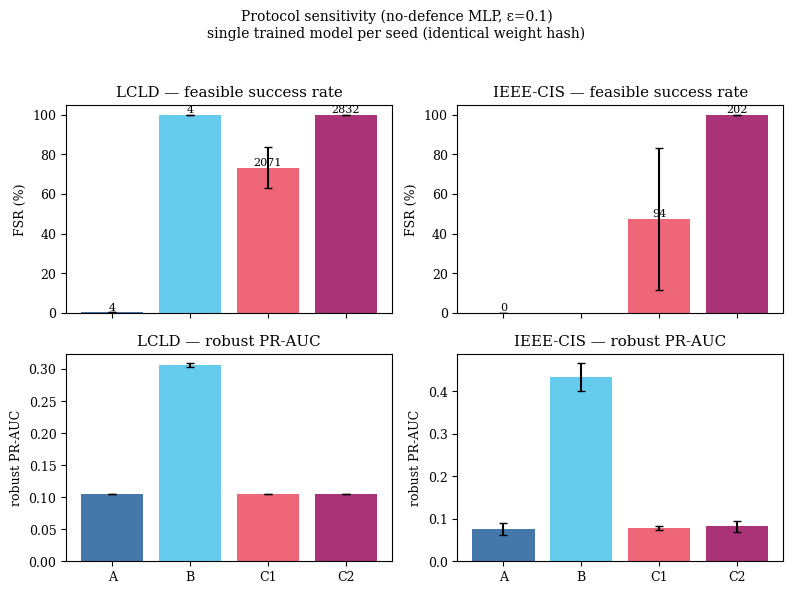

Saved fig_protocol_core.{pdf,png}


In [7]:
# Cell 11: fig_protocol_core (headline) — FSR + robust PR-AUC by protocol
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"font.family": "serif", "font.size": 9})
PROTO_ORDER = ["A_unconstrained", "B_posthoc_filter", "C1_projection", "C2_mask_projection"]
PROTO_LABEL = {"A_unconstrained": "A", "B_posthoc_filter": "B",
               "C1_projection": "C1", "C2_mask_projection": "C2"}
PROTO_COLOR = {"A_unconstrained": "#4477aa", "B_posthoc_filter": "#66ccee",
               "C1_projection": "#ee6677", "C2_mask_projection": "#aa3377"}

core = summ[(summ["defence"] == "none") & (summ["epsilon"] == 0.1)]
panels = ["LCLD", "IEEE-CIS"]
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex="col")
for j, ds in enumerate(panels):
    sub = core[core["dataset"] == ds].set_index("protocol")
    protos = [p for p in PROTO_ORDER if p in sub.index]
    x = np.arange(len(protos))
    colors = [PROTO_COLOR[p] for p in protos]
    # Row 1: FSR (%) with feasible-flipped count annotated.
    fsr = [sub.loc[p, "mean_fsr"] * 100 for p in protos]
    fsr_sd = [(sub.loc[p, "std_fsr"] or 0) * 100 for p in protos]
    ax = axes[0, j]
    ax.bar(x, fsr, yerr=fsr_sd, capsize=3, color=colors)
    for xi, p in zip(x, protos):
        ax.text(xi, fsr[xi] + 1, f"{sub.loc[p, 'mean_feasible_flipped_count']:.0f}",
                ha="center", fontsize=8)
    ax.set_title(f"{ds} — feasible success rate")
    ax.set_ylabel("FSR (%)")
    # Row 2: robust PR-AUC.
    pr = [sub.loc[p, "mean_robust_pr_auc"] for p in protos]
    pr_sd = [sub.loc[p, "std_robust_pr_auc"] or 0 for p in protos]
    ax2 = axes[1, j]
    ax2.bar(x, pr, yerr=pr_sd, capsize=3, color=colors)
    ax2.set_title(f"{ds} — robust PR-AUC")
    ax2.set_ylabel("robust PR-AUC")
    ax2.set_xticks(x)
    ax2.set_xticklabels([PROTO_LABEL[p] for p in protos])
fig.suptitle("Protocol sensitivity (no-defence MLP, ε=0.1)\n"
             "single trained model per seed (identical weight hash)", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.95])
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIG_DIR, f"fig_protocol_core.{ext}"),
                dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_protocol_core.{pdf,png}")

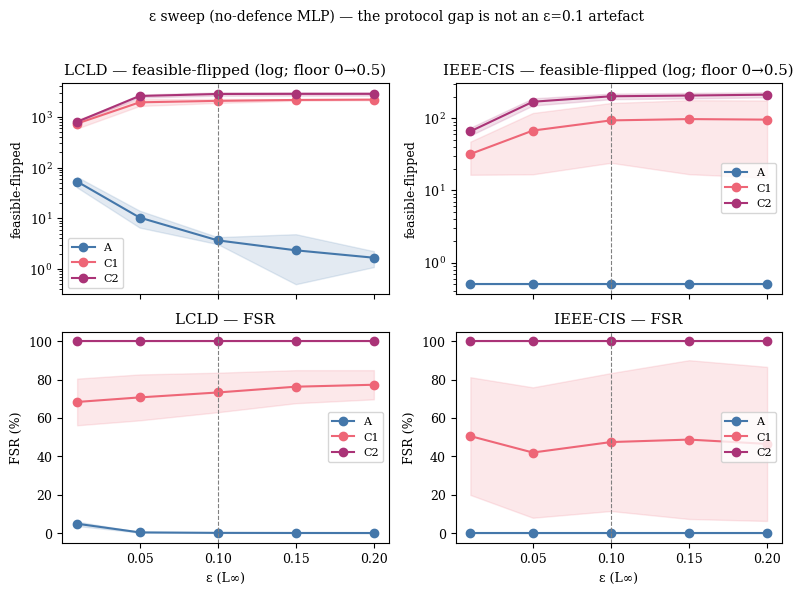

Saved fig_epsilon_sweep.{pdf,png}


In [8]:
# Cell 12: fig_epsilon_sweep — feasible-flipped + FSR vs ε (no-defence)
sweep = summ[summ["defence"] == "none"].copy()
panels = ["LCLD", "IEEE-CIS"]
sweep_protos = ["A_unconstrained", "C1_projection", "C2_mask_projection"]
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
for j, ds in enumerate(panels):
    sub = sweep[sweep["dataset"] == ds]
    for p in sweep_protos:
        s = sub[sub["protocol"] == p].sort_values("epsilon")
        if s.empty:
            continue
        eps = s["epsilon"].values
        ff = np.maximum(s["mean_feasible_flipped_count"].values, 0.5)  # log floor
        ff_sd = s["std_feasible_flipped_count"].fillna(0).values
        axes[0, j].plot(eps, ff, marker="o", color=PROTO_COLOR[p], label=PROTO_LABEL[p])
        axes[0, j].fill_between(eps, np.maximum(ff - ff_sd, 0.5), ff + ff_sd,
                                color=PROTO_COLOR[p], alpha=0.15)
        fsr = s["mean_fsr"].values * 100
        fsr_sd = s["std_fsr"].fillna(0).values * 100
        axes[1, j].plot(eps, fsr, marker="o", color=PROTO_COLOR[p], label=PROTO_LABEL[p])
        axes[1, j].fill_between(eps, fsr - fsr_sd, fsr + fsr_sd, color=PROTO_COLOR[p], alpha=0.15)
    axes[0, j].set_yscale("log")
    axes[0, j].set_title(f"{ds} — feasible-flipped (log; floor 0→0.5)")
    axes[0, j].set_ylabel("feasible-flipped")
    axes[1, j].set_title(f"{ds} — FSR")
    axes[1, j].set_ylabel("FSR (%)")
    axes[1, j].set_xlabel("ε (L∞)")
    for r in (0, 1):
        axes[r, j].axvline(0.1, ls="--", color="grey", lw=0.8)
        axes[r, j].legend(fontsize=8)
fig.suptitle("ε sweep (no-defence MLP) — the protocol gap is not an ε=0.1 artefact", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.96])
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIG_DIR, f"fig_epsilon_sweep.{ext}"),
                dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_epsilon_sweep.{pdf,png}")

In [9]:
# Cell 13: Back up deliverables to Drive
import shutil

DRIVE_OUT = "/content/drive/MyDrive/FraudBench/results/icdm_2026"
DRIVE_ADV = "/content/drive/MyDrive/FraudBench/results/adv_examples/icdm_capgd_grid"
os.makedirs(DRIVE_OUT, exist_ok=True)
os.makedirs(os.path.join(DRIVE_OUT, "figures"), exist_ok=True)
os.makedirs(DRIVE_ADV, exist_ok=True)

for f in [RESULTS_CSV, PERCON_CSV, SUMMARY_CSV]:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(DRIVE_OUT, os.path.basename(f)))
for f in os.listdir(FIG_DIR):
    shutil.copy(os.path.join(FIG_DIR, f), os.path.join(DRIVE_OUT, "figures", f))
for f in os.listdir(ADV_DIR):
    shutil.copy(os.path.join(ADV_DIR, f), os.path.join(DRIVE_ADV, f))
print(f"Backed up CSVs + figures -> {DRIVE_OUT}")
print(f"Backed up {len(os.listdir(ADV_DIR))} adversarial parquet -> {DRIVE_ADV}")

Backed up CSVs + figures -> /content/drive/MyDrive/FraudBench/results/icdm_2026
Backed up 294 adversarial parquet -> /content/drive/MyDrive/FraudBench/results/adv_examples/icdm_capgd_grid


## Notes

- **Same-model proof:** every protocol/ε row within a `(dataset, defence, seed)`
  shares one `model_weight_hash`; Cell 9 asserts it never drifts (the attack
  never updates weights). The mask enters the attack only — never training (§1.9.2).
- **Anchors (§4.4):** Cell 10 prints the no-defence ε=0.1 means; compare against
  LCLD/IEEE-CIS anchors. C2 may shift from the (between-model) thesis values —
  record material shifts in `notes`, do not force-fit.
- **Sparkov C2 mask** freezes victim geography/identity (documented default in
  `constraints/masks.py`); no §4.4 anchor exists for it.
- Feasibility uses the folded-OHE aggregate (`constraints/feasibility.py`), so
  Sparkov's `s_state_ohe` block is folded into the conjunction by construction.